## Import i analiza danych

In [1]:
from ucimlrepo import fetch_ucirepo

mushroom = fetch_ucirepo(id=73)
X = mushroom.data.features
y = mushroom.data.targets

print(f"X: {X.shape}, y: {y.shape}")
print(f"\nKolumny: {X.columns.tolist()}")
print(f"\nTarget rozkład:")
print(y['poisonous'].value_counts())

X: (8124, 22), y: (8124, 1)

Kolumny: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Target rozkład:
poisonous
e    4208
p    3916
Name: count, dtype: int64


In [2]:
print(f"\nNaN: {X.isnull().sum().sum()}")

X.head()


NaN: 2480


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [3]:
print("Unikalne wartości per cecha:")

for col in X.columns:
    vals = X[col].dropna().unique()
    print(f"  {col}: {X[col].nunique()} ({sorted(vals)})")

print("\nMissing per kolumna: ")
print(X.isnull().sum()[X.isnull().sum() > 0])

Unikalne wartości per cecha:
  cap-shape: 6 (['b', 'c', 'f', 'k', 's', 'x'])
  cap-surface: 4 (['f', 'g', 's', 'y'])
  cap-color: 10 (['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y'])
  bruises: 2 (['f', 't'])
  odor: 9 (['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y'])
  gill-attachment: 2 (['a', 'f'])
  gill-spacing: 2 (['c', 'w'])
  gill-size: 2 (['b', 'n'])
  gill-color: 12 (['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y'])
  stalk-shape: 2 (['e', 't'])
  stalk-root: 4 (['b', 'c', 'e', 'r'])
  stalk-surface-above-ring: 4 (['f', 'k', 's', 'y'])
  stalk-surface-below-ring: 4 (['f', 'k', 's', 'y'])
  stalk-color-above-ring: 9 (['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y'])
  stalk-color-below-ring: 9 (['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y'])
  veil-type: 1 (['p'])
  veil-color: 4 (['n', 'o', 'w', 'y'])
  ring-number: 3 (['n', 'o', 't'])
  ring-type: 5 (['e', 'f', 'l', 'n', 'p'])
  spore-print-color: 9 (['b', 'h', 'k', 'n', 'o', 'r', 'u', 'w', 'y'])
  population: 6 (['

In [ ]:
y = y.iloc[:, 0]

X = X.drop(columns=['veil-type'])

X = X.fillna('missing')

print(f"Po czyszczeniu: X={X.shape}, y={y.shape}")
print(f"NaN: {X.isnull().sum().sum()}")


Po czyszczeniu: X=(8124, 21), y=(8124,)
NaN: 0


In [ ]:
import pandas as pd

ct = pd.crosstab(X['odor'], y, normalize='index')
print(ct.round(3))

poisonous      e      p
odor                   
a          1.000  0.000
c          0.000  1.000
f          0.000  1.000
l          1.000  0.000
m          0.000  1.000
n          0.966  0.034
p          0.000  1.000
s          0.000  1.000
y          0.000  1.000


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), X.columns.tolist())
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6093, 21), Test: (2031, 21)


In [ ]:
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import pickle

def evaluate(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    
    # czas treningu
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = (time.perf_counter() - t0) * 1000
    
    # czas predykcji (10 powtórzeń)
    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        y_pred = pipe.predict(X_test)
        times.append(time.perf_counter() - t0)
    pred_time = np.mean(times) * 1000
    
    # metryki
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='p')
    rec = recall_score(y_test, y_pred, pos_label='p')
    f1 = f1_score(y_test, y_pred, pos_label='p')
    
    # rozmiar modelu
    model_size_kb = len(pickle.dumps(pipe)) / 1024
    
    return {
        'model': name,
        'accuracy': acc,
        'precision_poison': prec,
        'recall_poison': rec,
        'f1_poison': f1,
        'train_time_ms': train_time,
        'pred_time_ms': pred_time,
        'size_kb': model_size_kb,
    }

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

results = []

results.append(evaluate(
    'DecisionTree',
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test
))

results.append(evaluate(
    'LogisticRegression',
    LogisticRegression(max_iter=2000, random_state=42),
    X_train, X_test, y_train, y_test
))

results.append(evaluate(
    'RandomForest(n=100)',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test
))

pd.DataFrame(results).round(4)

,model,accuracy,precision_poison,recall_poison,f1_poison,train_time_ms,pred_time_ms,size_kb
0,DecisionTree,1.0000,1.0,1.000,1.0000,37.2332,7.4193,5.6260
1,LogisticRegression,0.9995,1.0,0.999,0.9995,112.6337,9.0383,3.8945
2,RandomForest(n=100),1.0000,1.0,1.000,1.0000,475.3205,89.5714,553.1670


In [10]:
depth_results = []
for d in [2, 3, 4, 5, 6, 7, 8, None]:
    r = evaluate(
        f'DT(max_depth={d})',
        DecisionTreeClassifier(max_depth=d, random_state=42),
        X_train, X_test, y_train, y_test
    )
    r['max_depth'] = d if d else 'None'
    depth_results.append(r)

pd.DataFrame(depth_results)[['model', 'accuracy', 'recall_poison', 'size_kb', 'pred_time_ms']].round(4)

,model,accuracy,recall_poison,size_kb,pred_time_ms
0,DT(max_depth=2),0.9513,0.9775,4.0615,8.3849
1,DT(max_depth=3),0.9828,0.9969,4.5303,7.6019
2,DT(max_depth=4),0.9916,0.9980,5.0020,7.4920
3,DT(max_depth=5),0.9990,0.9980,5.3145,7.7940
4,DT(max_depth=6),0.9990,0.9980,5.4707,8.8021
5,DT(max_depth=7),1.0000,1.0000,5.6270,7.6453
6,DT(max_depth=8),1.0000,1.0000,5.6270,9.4554
7,DT(max_depth=None),1.0000,1.0000,5.6260,7.7381


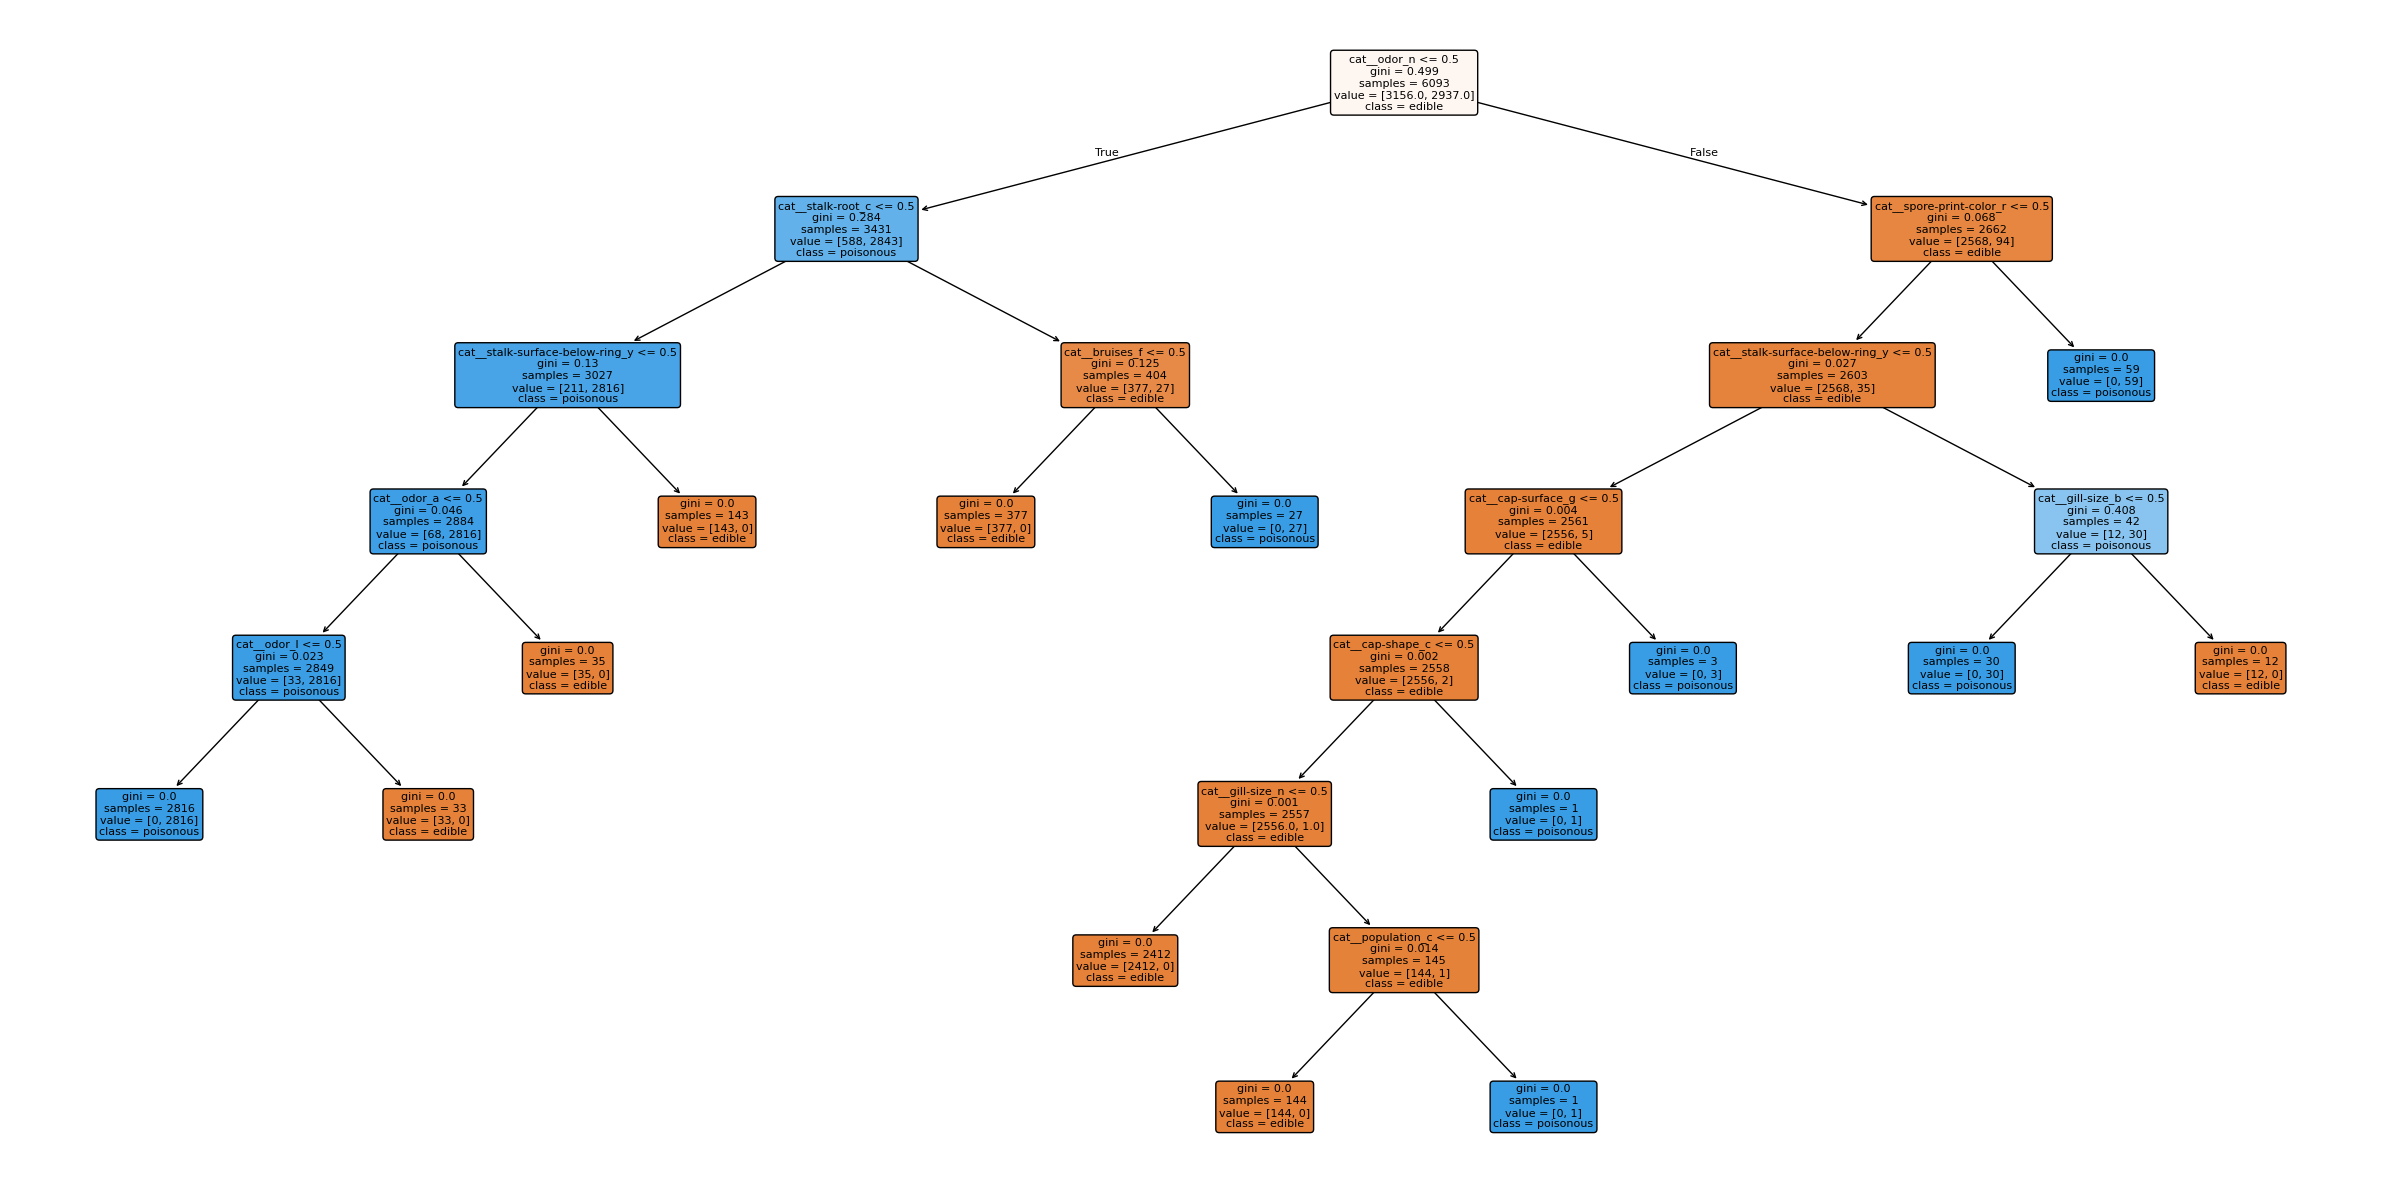

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_tree = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=7, random_state=42))
])
best_tree.fit(X_train, y_train)

feature_names = best_tree.named_steps['prep'].get_feature_names_out()

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    best_tree.named_steps['clf'],
    feature_names=feature_names,
    class_names=['edible', 'poisonous'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.tight_layout()
plt.show()

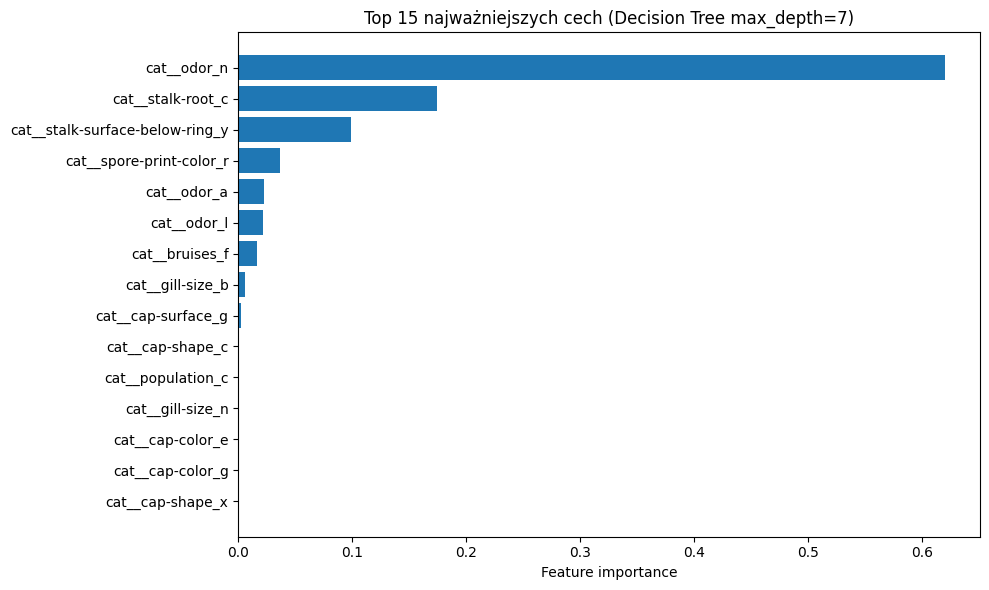

,feature,importance
27,cat__odor_n,0.620116
52,cat__stalk-root_c,0.174683
63,cat__stalk-surface-below-ring_y,0.099168
99,cat__spore-print-color_r,0.036911
22,cat__odor_a,0.022204
25,cat__odor_l,0.021441
20,cat__bruises_f,0.016562
35,cat__gill-size_b,0.005634
7,cat__cap-surface_g,0.001967
1,cat__cap-shape_c,0.000657


In [ ]:
importances = best_tree.named_steps['clf'].feature_importances_
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fi

## Podsumowanie i wnioski

Decision Tree (max_depth=7) osiąga 100% accuracy i 100% recall na klasie trujących grzybów, przy czasie predykcji 5ms i rozmiarze modelu 5.6 KB.

Random Forest dał ten sam wynik, ale waży 553 KB i robi predykcję w 61ms. Ensemble nie wnosi nic ponad pojedyncze drzewo, więc jego wybór byłby marnotrawstwem zasobów.

Regresja logistyczna ma 1 False Negative na 2031 grzybów, czyli raz uznała trującego za jadalnego. W tym zadaniu jedna taka pomyłka oznacza zatrucie, więc nawet 99.95% accuracy jest niewystarczające.

Drzewo opiera decyzję głównie na pięciu cechach: odor (62%), stalk-root (17%), stalk-surface-below-ring (10%), spore-print-color (4%) i kilku zapachach. Resztę cech ignoruje.